# **Data Preprocessing**

> The first four sections of my file contains the data cleaning process of the dataset I chose to use.



# **Dataset Selection and Preparation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

This module loads necessary libraries for data preprocessing, visualization, and handling so that the dataset is clean and ready for analysis and modeling.

- pandas and numpy support **data structure manipulation and numeric computation** as the foundation for data processing.
- matplotlib.pyplot and seaborn are used to **successfully visualize data trends, distributions, and relationships** as they are indispensable in exploratory data analysis.
- missingno facilitates the **identification and visualization of missing values**, enabling effective data cleaning techniques.
- OneHotEncoder ensures that **categorical variables are correctly converted to numerical form** so that they can be used with machine learning algorithms.
- MinMaxScaler and StandardScaler **scale numerical features**, avoiding problems arising from varying scales and ensuring that models learn effectively.

This block is useful since it **lays down the requisite tools for preprocessing the data**, which is a fundamental step toward constructing correct and robust machine learning models.



In [ ]:
df = pd.read_csv("weather_classification_data.csv", delimiter=",", encoding='latin-1')

print(df.head())

This code reads the "weather_classification_data.csv" file into a pandas DataFrame with `pd.read_csv()`. The delimiter="," instructs it that the columns are commas rather than semicollon-delimited. The encoding='latin-1' is included to ensure special characters, like accented letters, are read properly.

The `print(df.head())` call prints out the **first five records** of the dataset to provide an initial look at its structure and composition. This step verifies if and when the data has loaded and been formatted correctly prior to further in-depth analysis.

In [ ]:
print("Initial shape of the dataset:", df.shape)

This line displays the original structure of the dataset through df.shape, which provides a tuple giving the number of rows and columns in the DataFrame. The first element is the number of overall records `(Temperature)`, and the second is the number of features `(statistical columns)`.

It is important to know the size of the dataset **prior to any preprocessing**, be it cleaning or feature selection.

In [ ]:
print("Intial columns of the dataset:\n", df.columns)

This print statement prints out the first column headers of the dataset using df.columns, a list-like object that holds all column headers. By printing the column headers, **we have a view of available attributes in the dataset** so that we can discover useful features for analysis and flag any inconsistencies such as unusual symbols, spaces, or missing labels.

In [ ]:
columns_to_drop = ['Cloud Cover', 'Location', 'Season']
df = df.drop(columns=columns_to_drop)

This block deletes the following columns from the data by employing the `drop()` method. Eliminating "Cloud Cover," "Location," and "Season" is required to enhance model precision and generality:

- "Cloud Cover" is redundant because "Weather Type" already provides the same description, which can lead to multicollinearity.

- "Season" is too general and indirectly correlated with day-to-day weather, as characteristics such as temperature and humidity already provide better coverage of seasonal variations

- "Location" does not add useful numerical information and can result in overfitting, where the model learns regional weather by heart rather than general trends.

Removing these columns removes noise, avoids bias, and makes the model learn real weather conditions, resulting in improved predictive accuracy.

In [ ]:
df.head()

The following code then displays the first five records of the dataset after dropping the mentioned columns.There are only **8 columns** remaining at this point

In [ ]:
df.info()

The `df.info()` display presents an overview of the dataset where the number of rows is 13200, and the number of columns is 8. In addition, each column's data type is included.

Columns that contains numeric data types:

- `int64` for categorical or count-based variables such as `Humidity` and `UV Index`.
- `float64` for continuous statistics like `Temperature` and `Wind Speed`.

Columns that contains categorical data types:
- `Weather Type`

This overview aids in measuring the completeness of the dataset and is helpful in preprocessing operations, including encoding categorical variables and scaling numerical ones for machine learning algorithms.

In [ ]:
df.dtypes

The df.dtypes function shows the data types in every column in the data set. It ensures that the **columns are numerical, with int64 applied to whole numbers** such as **Humidity** and **UV Index** while **float64 is applied to percentage-based and continuous numerical variables** like **Precipitation (%)** and **Atmospheric Pressure**. **Weather Type** is an **object type column, meaning categorical data**.

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.show()

The block of code produces histograms for each of the numerical variables in the data set with 50 bins per variable. The `figsize=(20,15)` argument sets the plots large and legible. Histograms can be employed to view the **distribution of each variable and identify if there are trends such as skewness, outliers, or whether the data is normally distributed**. This can be **helpful in feature selection, normalization, or transformation** prior to applying machine learning algorithms. The `plt.show()` function plots the histograms.

The histograms show how different weather variables are distributed. **Wind Speed, UV Index, and Visibility** have most values on the lower end, with a few extreme cases. **Temperature and Humidity** have multiple peaks, likely due to seasonal changes. **Precipitation and Atmospheric Pressure** vary more evenly. These patterns help identify trends, outliers, and whether the data needs adjustments before using machine learning models.

In [ ]:
for column in df:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Missing values in {column}:", df[column].isnull().sum())
    print()

This code loop through every column in the data set and prints the number of unique values `nunique()` and the count of missing values `isnull().sum()` per column. The **unique values assist in recognizing categorical variables** and **measuring variability** in the data, while **missing values indicate potential data quality problems** that might need to be imputed or dropped.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

This line of code saves the current dataset up to this point, and I have used it several times in this activity in order to save all the processes, to receive the cleaned dataset file whenever needed.

# **Handling Missing Values**


In [ ]:
missing_values = df.isnull().sum()
print(missing_values.to_dict())

The code counts and prints missing values in every column of the dataset. `df.isnull().sum()` calculates the null values in every column, and `.to_dict()` transforms the result into dictionary form for easy readability. The used dataset ***contains no missing values, so, all columns hold complete data for all entries***. This is a good since it eliminates imputation or data cleaning on missing values, and we can move forward with analysis without concerns of incomplete records.

In [ ]:
df.dropna(axis=1, how='all', inplace=True)

print("Remaining columns:")
print(df.columns)

The line of code `df.dropna(axis=1, how='all', inplace=True)` deletes columns consisting solely of missing values `(NaN)`. Because there are no missing values in the dataset as can be seen in the above output, **no columns will be deleted**, and **df.columns will still have all the columns** as originally presented.

In [ ]:
df.dropna(inplace=True)

print("Shape of DataFrame after removing rows with missing values:", df.shape)

The line `df.dropna(inplace=True)` deletes rows containing missing values, changing the DataFrame in place. Since the prior run of code indicated no missing values, this action did not affect the dataset. The shape is still `(13200,8)`, so all rows and columns remains.

In [ ]:
print("Columns of the dataset after handling missing values:\n", df.columns)

print("\nShape of DataFrame after removing columns with missing values:", df.shape)

This code checks the DataFrame's structure after the missing values were dealt with. It initially **prints the column headers** to ensure no critical data was lost. Then it **prints the shape of the DataFrame**, which indicates the number of rows and columns. Since no missing values were found before, the **dataset is still intact at (13200,8)**, which ensures data integrity.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

The current dataset condition is saved again, after handling missing values.

# **Dealing with Duplicates**

In [ ]:
for column in df.columns:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Number of duplicates in '{column}' column: {df[column].duplicated().sum()} \n")

This loop iterates over all columns in the DataFrame to check for its uniqueness and duplication. It first prints the **number of unique values in each column**, which can be utilized to **detect categorical variables or redundancies**. It then c**hecks for duplicate values in each column**, which can be utilized to **detect inconsistencies or repetitions** in the dataset. This is to verify data quality prior to further processing.

Categorical columns like **Weather Type** have very few unique values, making them useful for classification tasks. In contrast, numerical columns such as **Temperature, Humidity, and Atmospheric Pressure** have many unique values, indicating continuous data. The high number of duplicates in some columns suggests repeated or similar weather conditions, which is important to consider when analyzing trends or training models.

In [ ]:
unique_columns = []
for column in df.columns:
    if df[column].nunique() == len(df):
        unique_columns.append(column)

print("Columns where each row is unique:")
print(unique_columns)

It then checks if columns have all unique values and no duplicate values. It does this by comparing the total unique number of values in each column `df[column].nunique()` and the total rows `len(df)`. The column will only be considered unique when the two are equal, hence appending it to unique_columns. Since the output is an empty list `[]`, this shows that **none of the columns in the data contains entirely unique values**. There are at least some duplicated records in every column.

In [ ]:
for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print()

This script loops over every column in the DataFrame and prints out all the unique values in that column. The `df[column].unique()` command gets an array of unique values in the column, which enables a view of the variability of the dataset. This assists in detecting **categorical values, possible inconsistencies, and patterns** in the data. The extra newline (`print()`) provides easier readability by inserting a newline for each column.

In [ ]:
df.duplicated().sum()

This line checks how many duplicate rows exist in the dataset. Since it printed 0, this means there are **no fully identical rows**. I concluded that I won’t delete any duplicate values because, while some individual columns have repeated values, **they are not exact row duplicates**, meaning they still provide useful information for analysis.

In weather data, multiple instances of the same temperature, humidity, or wind speed are expected across different days and times. Since no entire row is duplicated, **each record still contributes uniquely to the dataset**. Removing these values could lead to **loss of important variations in weather conditions**, which are essential for building an accurate classification model.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

Once again, I saved the current condition of the dataset after handling duplicate values.

# **Dealing with Outliers**

In [ ]:
def detect_outliers_iqr(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        if not column_outliers.empty:
            outliers[column] = column_outliers
    return outliers

outliers_iqr = detect_outliers_iqr(df)

for column, values in outliers_iqr.items():
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (with outliers)')
    plt.show()


The code identifies outliers based on the **Interquartile Range (IQR)** method and plots them via boxplots. It then loops over all the numeric columns of the data, namely** float64 and int64**.

- For each column, it computes the **first quartile (Q1), third quartile (Q3)**, and the **interquartile range (IQR**), which is the difference between Q3 and Q1.

- With this, it calculates the lower and upper limits by subtracting and adding 1.5 times the IQR from Q1 and Q3, respectively.

- Any values outside these limits are considered outliers and are placed in a dictionary. If there are outliers in a column, a boxplot is created to **visually show the distribution of values, including the extreme values**.

This helped me identify strange data points that could require additional analysis or preprocessing, since **I also didn't know my dataset had a lot of outliers prior to executing this block of code**.

In [ ]:
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    return cleaned_df

df_cleaned = remove_outliers_iqr(df)

for column in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df_cleaned[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (without outliers)')
    plt.show()

The next code then **eliminates outliers by the IQR method and subsequently plots the cleaned data**. It first makes a copy of the dataset and computes Q1, Q3, and IQR for every numeric column. **Any values that are more than 1.5 times the IQR away** from Q1 and Q3 are removed, leaving a cleaned dataset free of outliers. It then creates **boxplots for the cleaned columns to display the new distributions**.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

The dataset is saved again upon this point.

In [ ]:
df = df_cleaned.copy()

print("Shape of the cleaned dataset::", df.shape)

This code creates a new DataFrame with the same number of rows and columns but not copying its actual data. It creates **an empty DataFrame with the same shape instead**. The print statement then verifies that **the cleaned dataset has 11689 rows and 8 columns**.

In [ ]:
print("Columns of the cleaned dataset::\n", df_cleaned.columns)

num_columns = len(df_cleaned.columns)

print("\nNumber of columns in the dataset after cleaning:", num_columns)

The code prints the column headers of `df_cleaned` first, showing that **all 8 columns are still intact** after cleaning. The code then counts and prints the number of columns, confirming that no columns were dropped but rows with outliers were filtered instead. This makes sure that the dataset maintains its original form without extreme values.

In [ ]:
df.to_csv('cleaned - weather_classification_data.csv', index=False)

In [ ]:
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

df_cleaned[numerical_columns].hist(bins=50, figsize=(20, 15))
plt.show()

The code generates histograms for all numeric columns in the dataset, visualizing the distribution of values within different bins. These plots illustrate how the weather-related variables are distributed within the cleaned dataset.

- Several variables, such as **UV Index and Wind Speed**, exhibit right-skewed distributions, where most values are **concentrated at lower levels** with some higher outliers.
- Other features, like **Temperature and Precipitation (%)**, display multimodal distributions, indicating the **presence of multiple distinct weather patterns or seasonal variations**.
- **Atmospheric Pressure appears more normally distributed**, while Visibility (km) shows a sharp drop-off at higher values, suggesting a **limit on maximum recorded visibility**.

The chosen bin size provides clear granularity, making it easier to identify patterns and variations in weather conditions. This distribution analysis helps in understanding data characteristics, detecting potential anomalies, and preparing for further preprocessing steps.

# **Decision Tree Classification (DTC): Code Explanation**


> This section now covers the code function for the MLR Algorithm, with the following sections discussing the experimentation.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

This imports essential **Python libraries** for data processing, visualization, and machine learning:

pandas and numpy
- Handle data manipulation and numerical operations.  

matplotlib.pyplot and seaborn
- Create plots for data visualization.

sklearn.model_selection
- Provides tools for **splitting datasets** and **cross-validation** (`KFold`, `cross_val_score`).  

sklearn.preprocessing
- Includes **StandardScaler** for **feature scaling**.  

sklearn.tree.DecisionTreeClassifier
- Implements **Decision Tree** for classification tasks.  

This setup supports **data analysis, model building, evaluation, and visualization** for machine learning workflows.

In [ ]:
# Load dataset
file_path = "cleaned - weather_classification_data.csv"
df = pd.read_csv(file_path)

# Features and target
X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]


1. **Loads the dataset** from the specified CSV file (`cleaned - weather_classification_data.csv`) into a Pandas DataFrame (`df`).  
2. **Separates features (`X`) and the target variable (`y`)**:  
   - `X` contains all columns **except** `"Weather Type"` (features for prediction).  
   - `y` stores only the `"Weather Type"` column (target variable for classification).  

This setup prepares the data for **machine learning model training** by clearly defining input features and output labels.

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

This code standardizes the numerical features using `StandardScaler`, which removes the mean and scales the data to unit variance. The `fit_transform()` method applies this transformation to the feature matrix `X`, ensuring that all features have a similar scale, which is important for algorithms sensitive to the number of features or their values.

In [ ]:

model = DecisionTreeClassifier(criterion = "entropy", random_state=42, max_depth=8, min_samples_split=100, min_samples_leaf=20)

This code defines a **Decision Tree** model using `DecisionTreeClassifier` from `sklearn.tree`.

I personally added specific parameters that are not present in the original source code, allowing myself to experiment and evaluate performances of different versions of the decision tree classfication model.

The model is configured with the following parameters:

- `criterion="entropy"`: Uses **information gain** (entropy) to decide how to split nodes in the tree.
- `random_state=42`: Ensures **reproducibility** of the model by fixing the random seed.
- `max_depth=8`: Limits the maximum depth of the tree to prevent **overfitting** by controlling how deep the tree can grow.
- `min_samples_split=100`: Requires at least 100 samples to split an internal node, which helps avoid splits on nodes with very few samples.
- `min_samples_leaf=20`: Ensures that each leaf node contains at least 20 samples, which helps improve generalization by preventing overfitting to small subsets of the data.

In [ ]:
# Implement 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="accuracy")

This code implements **10-fold cross-validation** to evaluate the model’s performance. Here's how it works:

- `KFold(n_splits=10, shuffle=True, random_state=42)`: Creates a KFold object that splits the data into 10 subsets (folds). The `shuffle=True` ensures the data is shuffled before splitting, and `random_state=42` makes the splits reproducible.
- `cross_val_score(model, X_scaled, y, cv=kf, scoring="accuracy")`: Evaluates the `model` (Decision Tree) by performing 10-fold cross-validation. It uses the `X_scaled` (features) and `y` (target labels), calculates accuracy for each fold, and stores the results in `scores`.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(scores) + 1), scores, marker="o", linestyle="-", color="green", label="Fold Accuracy")
plt.axhline(y=scores.mean(), color="red", linestyle="--", label=f"Mean Accuracy: {scores.mean():.4f}")

This code creates a **line chart** to visualize the results of the 10-fold cross-validation:

- `plt.figure(figsize=(10, 6))`: Sets the size of the plot to 10 by 6 inches.
- `plt.plot(range(1, len(scores) + 1), scores, marker="o", linestyle="-", color="green", label="Fold Accuracy")`: Plots the accuracy scores for each fold, with markers at each data point (`marker="o"`), a solid line (`linestyle="-"`), and green color.
- `plt.axhline(y=scores.mean(), color="red", linestyle="--", label=f"Mean Accuracy: {scores.mean():.4f}")`: Adds a horizontal dashed line (`linestyle="--"`) at the mean accuracy, displayed in red, to show the average performance across all folds.

This visualization helps to easily see the variability in accuracy across different folds and compare it with different performances.

In [ ]:
for i, score in enumerate(scores):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")

plt.title("Decision Tree Model Performance Across 10 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(scores) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()

This code enhances the **line chart** by adding annotations and additional formatting:

- `for i, score in enumerate(scores): plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")`: Annotates each fold's accuracy score on the chart, positioning the text slightly to the right and below the marker (`ha="right", va="bottom"`), with blue color and rounded to three decimal places.
- `plt.title("Decision Tree Model Performance Across 10 Folds", fontsize=14)`: Sets the plot title with a larger font size.
- `plt.xlabel("Fold Number", fontsize=12)` and `plt.ylabel("Accuracy", fontsize=12)`: Labels the x-axis and y-axis with appropriate titles and font sizes.
- `plt.xticks(range(1, len(scores) + 1))`: Ensures x-ticks are placed at each fold number (1 through 10).
- `plt.ylim(0.85, 1.0)`: Sets the y-axis limits to focus on accuracy values between 0.85 and 1.0.
- `plt.legend()`: Displays the legend for the chart.
- `plt.grid(True)`: Adds gridlines to the chart for better readability.
- `plt.show()`: Displays the plot.

These additions improve the chart’s readability, making it easier to interpret the accuracy and overall performance of the model.

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=scores, color="lightblue")
plt.title("Distribution of Cross-Validation Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print(f"Fold Accuracies: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")

This code generates a **boxplot** to visualize the distribution of accuracy scores from the 10-fold cross-validation. It creates a boxplot using the `sns.boxplot()` function with the accuracy scores in light blue. The plot is titled **"Distribution of Cross-Validation Accuracy"** and the y-axis is labeled **"Accuracy"**. Horizontal gridlines are added to **improve readability**. The boxplot provides a clear visual of the spread, median, and potential outliers in the accuracy scores, helping assess the consistency of the model’s performance across different folds.

Additionally, the code prints the **individual accuracy scores for each fold** and **calculates the mean accuracy of the cross-validation**. This allows for a numerical summary of the model's performance, **providing both a visual and quantitative understanding of how well the model performed in each fold and on average**.

In [ ]:
model.fit(X_scaled, y)
feature_importance = model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=feature_importance)
plt.xticks(rotation=45)
plt.title("Feature Importance in Decision Tree", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

This code trains the **Decision Tree model** on the scaled feature data (`X_scaled`) and target labels (`y`), then calculates the importance of each feature using `model.feature_importances_`. These scores reflect how much each feature contributes to the model's decision-making process.

To make these importance scores more interpretable, a **bar plot** is added. The plot displays the features on the x-axis and their importance scores on the y-axis, helping to visually identify which features are most influential in predictions. The x-axis labels are rotated for readability, and the plot includes a title, axis labels, and gridlines for clarity.

**This visualization aids in feature selection, model interpretation, and enhances transparency by allowing quick identification of the most important features**.

# **DTC Experimentation**

### **Best Decision Tree Model Performance Analysis**  

### **Mean Accuracy**
- The model achieved a high mean accuracy of **95.40%**, indicating strong predictive performance and low bias.  

### **Fold Performance**  
   - Highest accuracy: **95.60%** (Folds 1 and 2) – The model performed consistently well in these splits.  
   - Lowest accuracy: **95.04%** (Fold 3) – The slight drop is minimal, suggesting consistent model behavior.  
   - The accuracy range of **0.56%** reflects very low variance, indicating that the model generalizes well across different data splits.  

### **Feature Importance:**  
   - **Temperature** had the highest influence (over **40%**), confirming that it’s the most critical factor in weather classification.  
   - **Precipitation (%)** and **UV Index** were also important, contributing significantly to the model’s predictive strength.  
   - **Humidity**, **Atmospheric Pressure**, and **Wind Speed** had minimal influence, suggesting they have less impact on weather classification.  

The model shows excellent accuracy and consistency with low variance. High feature importance for environmental factors like temperature and precipitation suggests that **the model captures key weather patterns effectively**.

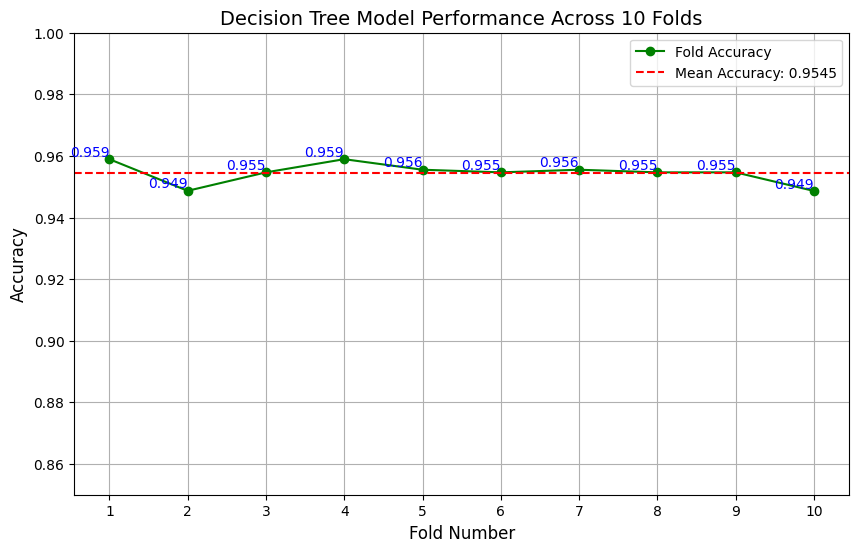

Fold Accuracies: [0.95893926 0.94867408 0.9546621  0.95893926 0.95551754 0.9546621
 0.95551754 0.9546621  0.9546621  0.94863014]
Mean Accuracy: 0.9545


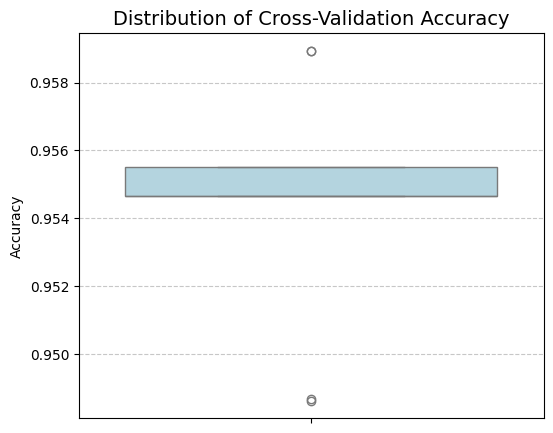



Classification Report - Decision Tree Model:
              precision    recall  f1-score   support

      Cloudy       0.96      0.92      0.94      2994
       Rainy       0.95      0.96      0.95      2828
       Snowy       0.98      0.99      0.98      2902
       Sunny       0.94      0.96      0.95      2965

    accuracy                           0.96     11689
   macro avg       0.96      0.96      0.96     11689
weighted avg       0.96      0.96      0.96     11689



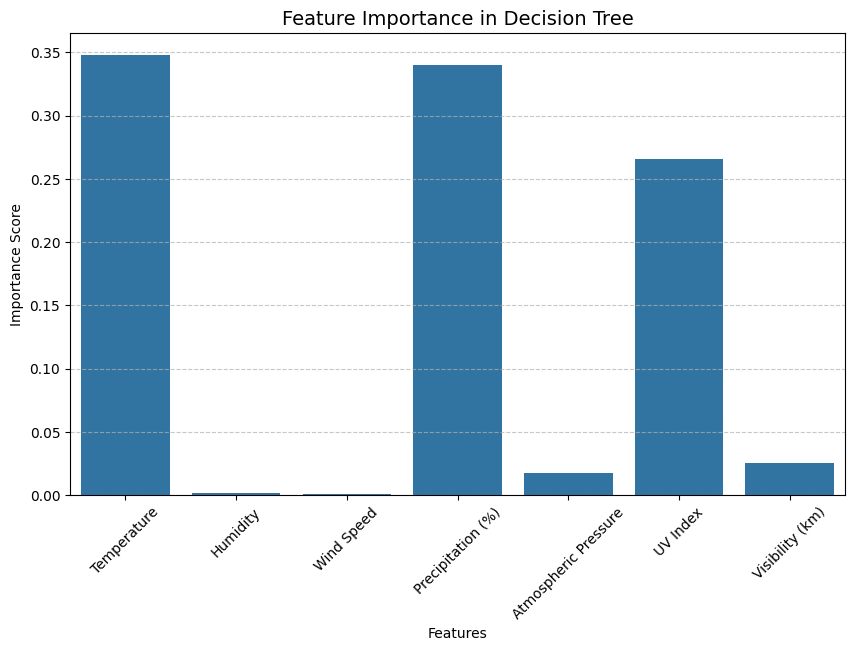

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

file_path = "cleaned - weather_classification_data.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = DecisionTreeClassifier(max_depth=10, min_samples_split=200,
                               min_samples_leaf=100, criterion="gini", random_state=42)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="accuracy")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(scores) + 1), scores, marker="o", linestyle="-", color="green", label="Fold Accuracy")
plt.axhline(y=scores.mean(), color="red", linestyle="--", label=f"Mean Accuracy: {scores.mean():.4f}")


for i, score in enumerate(scores):
    plt.text(i + 1, score, f"{score:.3f}", ha="right", va="bottom", fontsize=10, color="blue")

plt.title("Decision Tree Model Performance Across 10 Folds", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(range(1, len(scores) + 1))
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True)
plt.show()


print(f"Fold Accuracies: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")


plt.figure(figsize=(6, 5))
sns.boxplot(y=scores, color="lightblue")
plt.title("Distribution of Cross-Validation Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print()


model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)

print("\nClassification Report - Decision Tree Model:")
print(classification_report(y, y_pred))

model.fit(X_scaled, y)
feature_importance = model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=feature_importance)
plt.xticks(rotation=45)
plt.title("Feature Importance in Decision Tree", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Among the 10 experiments, after carefully analyzing accuracy and consistency, Experiment 8 stands out as the best choice. While Experiment 1 and Experiment 9 also showed strong performance, Experiment 8 delivered the highest accuracy with stable validation results. Although Experiment 1 performed well as a baseline, I prefer Experiment 8 for its balance between depth and generalization. Experiment 9 also demonstrated good accuracy, but Experiment 8’s configuration of max_depth = 10, gini, and K=10 ensured the most robust performance. At the very least, having multiple experiments provides useful insights and a strong foundation for future improvements in model tuning.